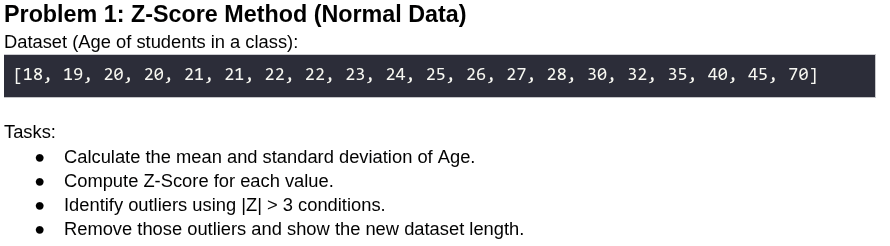

In [87]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [88]:
df = pd.DataFrame([18, 19, 20, 20, 21, 21, 22, 22, 23, 24, 25, 26, 27, 28, 30, 32, 35, 40, 45, 70], columns=['Age'])
df

,Age
0,18
1,19
2,20
3,20
4,21
5,21
6,22
7,22
8,23
9,24


In [89]:
mn = df["Age"].mean()
std = df["Age"].std()
print(f"mean:{mn}, and standard deviaion: {std}")

mean:28.4, and standard deviaion: 12.132600710482482


<Axes: xlabel='Age', ylabel='Density'>

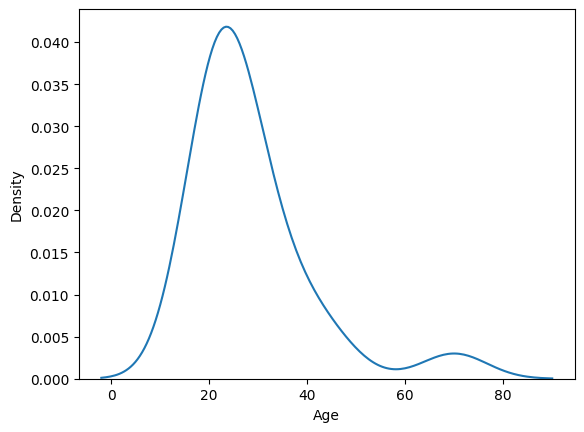

In [90]:
sns.kdeplot(data = df, x = 'Age')

In [91]:
df["Zscore_Age"] = abs((df["Age"] - mn) / std)
# display(df["Zscore_Age"])
outlires = df["Zscore_Age"] > 3


In [92]:
df = df[df["Zscore_Age"] < 3]
display(len(df))

19

In [93]:
df.drop(columns="Zscore_Age", inplace=True)
display(df)

/tmp/ipykernel_7841/1447020674.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns="Zscore_Age", inplace=True)


,Age
0,18
1,19
2,20
3,20
4,21
5,21
6,22
7,22
8,23
9,24


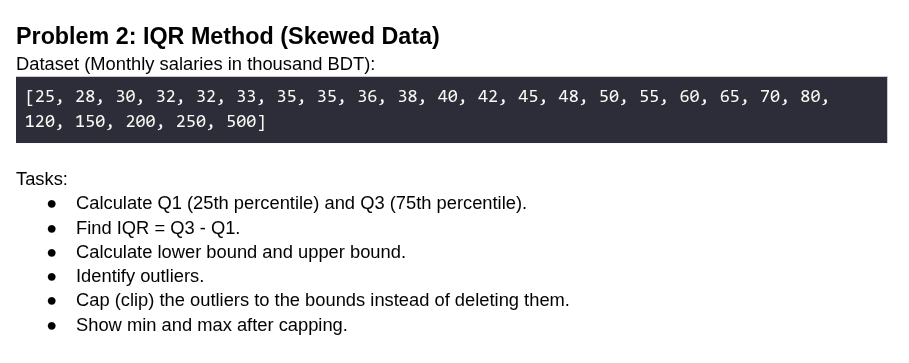

In [94]:
df = pd.DataFrame([25, 28, 30, 32, 32, 33, 35, 35, 36, 38, 40, 42, 45, 48, 50, 55, 60, 65, 70, 80, 120, 150, 200, 250, 500], columns=["salary"])
display(len(df))

25

In [95]:
q1 = df["salary"].quantile(0.25)
q3 = df["salary"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - (iqr * 1.5)
upper_bound = q3 + (iqr * 1.5)


df["salary"] = df["salary"].clip(
    lower=lower_bound,
    upper=upper_bound
)

mx = df["salary"].max()
mn = df["salary"].min()
length = len(df)

print(f"Minimum value: {mn}, maximum value: {mx}, length: {length}")

Minimum value: 25.0, maximum value: 122.5, length: 25


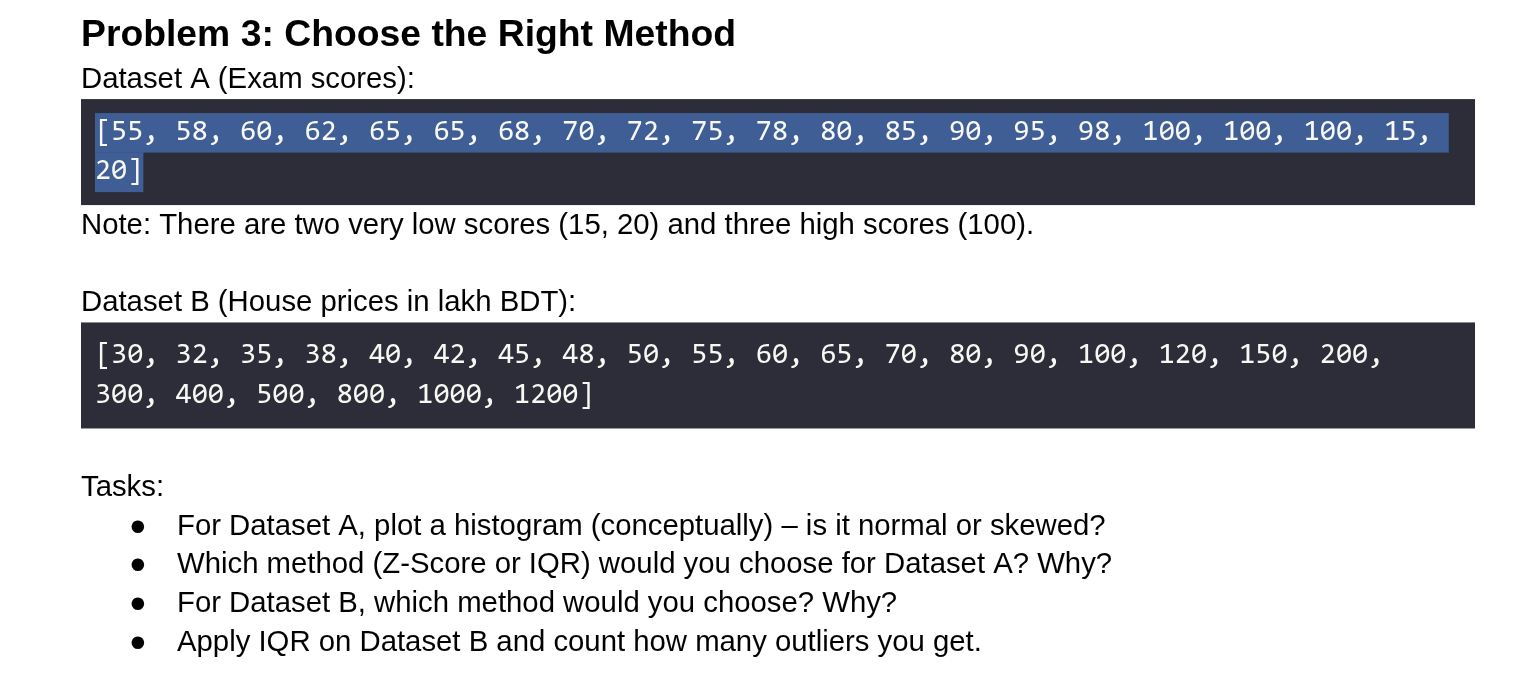

In [97]:
A = pd.DataFrame([55, 58, 60, 62, 65, 65, 68, 70, 72, 75, 78, 80, 85, 90, 95, 98, 100, 100, 100, 15, 20], columns=["Exam_score"])
B = pd.DataFrame([30, 32, 35, 38, 40, 42, 45, 48, 50, 55, 60, 65, 70, 80, 90, 100, 120, 150, 200, 300, 400, 500, 800, 1000, 1200], columns=["House_price"])

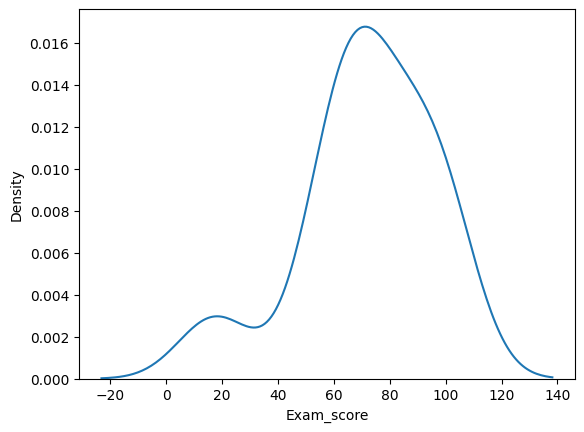

In [ ]:
sns.kdeplot(data = A, x = "Exam_score")
plt.show()

# it is right skeewed so that IQR method wil be suitable for this data

In [105]:
q1 = B["House_price"].quantile(.25)
q3 = B["House_price"].quantile(.75)

iqr = q3 - q1

cnt = ((B["House_price"] >=( q1 - (iqr * 1.5))) &  (B["House_price"] <=( q3 + (iqr * 1.5)))).sum()
print(f"It has {cnt} outlires.")
display(len(B))

It has 21 outlires.


25

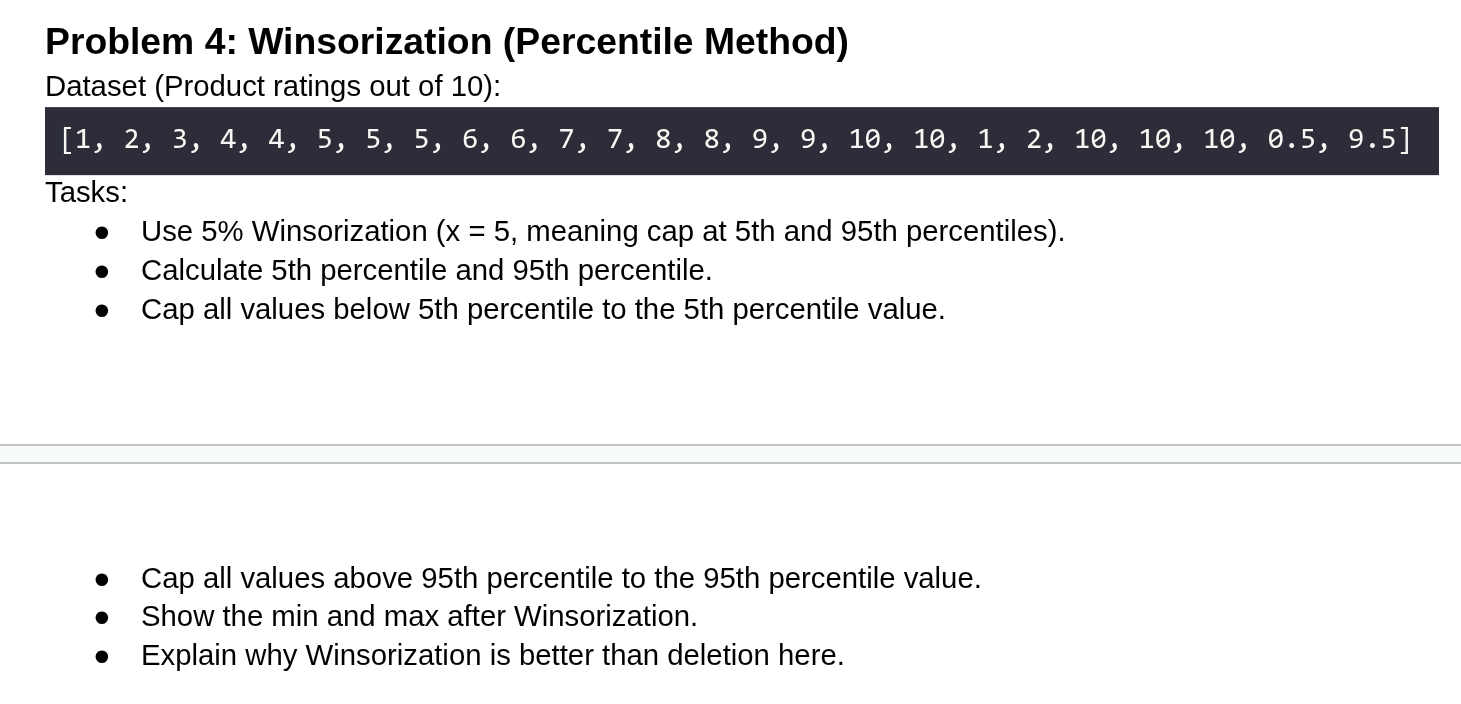

In [108]:
R = pd.DataFrame([1, 2, 3, 4, 4, 5, 5, 5, 6, 6, 7, 7, 8, 8, 9, 9, 10, 10, 1, 2, 10, 10, 10, 0.5, 9.5], columns=["rating"])

x = 5
x = x / 100 

lower = R["rating"].quantile(x)
upper = R["rating"].quantile(1 - x)

print(f"lower value {lower} and upper vlaue {upper}")

R["rating"] = R["rating"].clip(lower, upper)

print(f"after winsorization min{R["rating"].min()} and maximun {R["rating"].max()}")

lower value 1.0 and upper vlaue 10.0
after winsorization min1.0 and maximun 10.0
